In [22]:
import pandas as pd
import re
import numpy as np
from scipy.stats import zscore
from toolbox_library import Calendar
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import date
from dateutil.relativedelta import relativedelta

# 載入台股前500大資料以及VIX指數

In [30]:
calendar = Calendar(start_date='2020-01-01',
                    end_date='2024-12-31',
                    rebalance_time_period='Quarter')

adj_close_df = pd.read_csv("(Adj Close)台股前500大歷史資料.csv", index_col=0, parse_dates=True)
adj_close_df.index = adj_close_df.index.date
reb_intervals = calendar.rebalance_day_intervals

In [117]:
VIX_df = yf.download('^VIX', '2015-01-01','2025-01-10', progress=False)['Adj Close']
VIX_df = VIX_df.to_frame(name='VIX')
VIX_df.index = VIX_df.index.date

# 傅立葉轉換函數

In [32]:
def batch_low_pass_filter(df, cutoff=0.1):
    """
    對整個數據框進行批量低通濾波，去除高頻部分。

    參數：
    - df: 數據框，每列是一隻股票的時間序列數據。
    - cutoff: 截止頻率，值越小保留的低頻越少。

    返回：
    - 濾波後的數據框
    """
    # 確保數據是 numpy array
    data = df.to_numpy()
    
    # 執行傅立葉變換 (批量處理)
    fft_result = np.fft.fft(data, axis=0)
    frequencies = np.fft.fftfreq(data.shape[0])  # 計算頻率
    
    # 構建濾波器
    filter_mask = np.abs(frequencies) <= cutoff
    fft_result[~filter_mask, :] = 0  # 應用濾波器
    
    # 逆傅立葉變換並保留實部
    filtered_data = np.fft.ifft(fft_result, axis=0).real
    
    # 將結果轉回數據框，保持索引和列名
    return pd.DataFrame(filtered_data, index=df.index, columns=df.columns)

# 計算動能以及波動度函數

In [33]:
def calculate_momentum(prev_day, lookback=6, cutoff=0.1):
    #prev_day = pd.Timestamp(prev_day)  # 確保是 Timestamp 格式
    ten_years_ago = prev_day - relativedelta(years=10)
    
    filtered_data = batch_low_pass_filter(adj_close_df[ ten_years_ago  : prev_day], cutoff)
    
    # 使用 get_loc() 獲取索引位置
    prev_day_idx = filtered_data.index.get_loc(prev_day)
    old_day_idx = prev_day_idx - lookback
    
    return filtered_data.iloc[prev_day_idx] / filtered_data.iloc[old_day_idx]

def calculate_volatility(prev_day, lookback=6, cutoff=0.1):
    #prev_day = pd.Timestamp(prev_day)  # 確保是 Timestamp 格式
    ten_years_ago = prev_day - relativedelta(years=10)
    
    filtered_data = batch_low_pass_filter(adj_close_df[ ten_years_ago  : prev_day], cutoff)

    prev_day_idx = filtered_data.index.get_loc(prev_day)
    old_day_idx = prev_day_idx - lookback*21
    return filtered_data[old_day_idx : prev_day_idx+1].std()

# 開始回測策略

In [84]:
import numpy as np
import pandas as pd

initial_capital = 100
df_list = []

# 回測策略
for idx in range(1, len(reb_intervals)):
    #print(reb_intervals[idx])
    
    curr_date_interval = reb_intervals[idx]
    prev_date_interval = reb_intervals[idx - 1]
    
    bt_start_date, bt_end_date = curr_date_interval[0], curr_date_interval[1]  # bt = back test
    previous_day = prev_date_interval[-1]
    
    cutoff = 0.1
    m1 = calculate_momentum(previous_day, lookback=6, cutoff=cutoff)
    m2 = calculate_momentum(previous_day, lookback=15, cutoff=cutoff)
    m3 = calculate_momentum(previous_day, lookback=30, cutoff=cutoff)

    momentum = (m1 * m2 * m3).dropna()
    volatility = calculate_volatility(previous_day, cutoff=cutoff).dropna()

    common_index = momentum.index.intersection(volatility.index)
    momentum = momentum[common_index]
    volatility = volatility[common_index]

    scores = -zscore(momentum) - zscore(volatility) / 2
    only_long = True  # 只做多頭交易
    
    if only_long:
        selected_stocks = scores.nlargest(10).index
        selected_scores = scores[selected_stocks]

        # 取得選定股票的報酬率
        portfolio = adj_close_df[selected_stocks].pct_change(fill_method=None)
        portfolio = portfolio.join(VIX_df, how="outer")
        portfolio = portfolio[bt_start_date:bt_end_date]
        portfolio["VIX"] = portfolio["VIX"].fillna(-1).shift(1)

        cols_to_modify = portfolio.columns[portfolio.columns != "VIX"]
        portfolio[cols_to_modify] = portfolio.apply(
            lambda row: row[cols_to_modify] * (-1) if row["VIX"] > 25 else row[cols_to_modify],
            axis=1
        )
        portfolio = portfolio.drop(columns=["VIX"])

    # **新增單一股票停損**
    threshold = -0.05  # **-5% 停損門檻**
    cumulative_return = (portfolio + 1).cumprod() - 1  # **計算累積報酬率**
    mask = np.zeros(portfolio.shape, dtype=bool)

    for col in portfolio.columns:
        stop_idx = np.where(cumulative_return[col] <= threshold)[0]  # **找到跌破 -5% 的時間索引**
        if len(stop_idx) > 0:
            mask[stop_idx[0]:, portfolio.columns.get_loc(col)] = True  # **停損後該股票報酬設為 0**

    portfolio[mask] = 0  # **套用停損**

    # **計算權重**
    weights = np.exp(selected_scores) / np.sum(np.exp(selected_scores))
    weighted_portfolio = portfolio.mul(weights, axis=1)

    # **計算當季回報率**
    weighted_returns = weighted_portfolio.sum(axis=1)[bt_start_date:bt_end_date]
    cumulative_returns = (1 + weighted_returns).cumprod()

    # **如果整體策略跌超過 -5%，則之後維持該跌幅**
    if not cumulative_returns.loc[cumulative_returns < 0.95].empty:
        first_idx = cumulative_returns.loc[cumulative_returns < 0.95].index[0]
        cumulative_returns[first_idx:] = cumulative_returns[first_idx]

    cumulative_returns = cumulative_returns * initial_capital
    df_list.append(cumulative_returns)

    # **更新初始資本**
    initial_capital = cumulative_returns.iloc[-1]

# **合併各季度的累積回報**
strategy_result = pd.concat(df_list, axis=0)
print(strategy_result)


2016-01-04      99.257753
2016-01-05      98.928833
2016-01-06      98.817597
2016-01-07      98.175984
2016-01-08      98.454364
                 ...     
2024-12-24    1683.666740
2024-12-25    1684.471090
2024-12-26    1684.385574
2024-12-27    1683.533846
2024-12-30    1692.073277
Length: 2324, dtype: float64


In [89]:
strategy_result.index = pd.to_datetime(strategy_result.index)

# 畫出收益曲線

年化 Sharpe Ratio: 1.6668


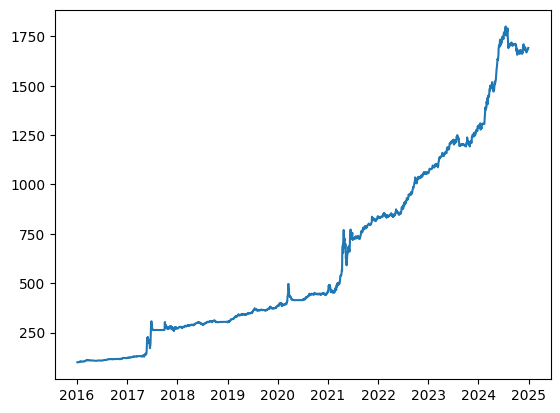

In [90]:
plt.plot(strategy_result.index, strategy_result.values)
import numpy as np

# 計算日報酬率
daily_returns = strategy_result.pct_change().dropna()

# 設定無風險利率 (通常設為 0)
risk_free_rate = 0

# 計算日 Sharpe Ratio
sharpe_ratio_daily = (daily_returns.mean() - risk_free_rate) / daily_returns.std()

# 轉換為年化 Sharpe Ratio
sharpe_ratio_annualized = sharpe_ratio_daily * np.sqrt(252)

print(f"年化 Sharpe Ratio: {sharpe_ratio_annualized:.4f}")


# 比較策略與大盤(0050)的return和Sharpe ratio

In [108]:
import yfinance as yf
import numpy as np
import pandas as pd

# **下載 0050 (元大台灣50) 的歷史數據**
etf_0050 = yf.download("0050.TW", start="2016-01-01", end="2024-12-31", progress = False)["Adj Close"]

# **計算 0050 的日報酬率**
etf_0050_returns = etf_0050.pct_change().dropna()

# **計算 0050 的累積報酬**
cumulative_etf_0050 = (1 + etf_0050_returns).cumprod()

# **分割 `strategy_result`**
train_strategy = strategy_result["2016-01-01":"2019-12-31"]
test_strategy = strategy_result["2020-01-01":"2024-12-31"]

# **分割 0050**
train_0050 = cumulative_etf_0050["2016-01-01":"2019-12-31"]
test_0050 = cumulative_etf_0050["2020-01-01":"2024-12-31"]

# **計算 Annual Return**
def annual_return(cumulative_returns, years):
    return (cumulative_returns.iloc[-1] / cumulative_returns.iloc[0]) ** (1 / years) - 1

train_strategy_return = annual_return(train_strategy, 4)  # 訓練期 (4年)
test_strategy_return = annual_return(test_strategy, 5)    # 測試期 (5年)

train_0050_return = annual_return(train_0050, 4)
test_0050_return = annual_return(test_0050, 5)

# **計算 Sharpe Ratio**
def sharpe_ratio(returns, risk_free_rate=0.02):
    excess_returns = returns - risk_free_rate / 252  # 252 交易日
    return excess_returns.mean() / excess_returns.std() * np.sqrt(252)

train_strategy_sharpe = sharpe_ratio(train_strategy.pct_change().dropna())
test_strategy_sharpe = sharpe_ratio(test_strategy.pct_change().dropna())

train_0050_sharpe = sharpe_ratio(etf_0050_returns["2016-01-01":"2019-12-31"])
test_0050_sharpe = sharpe_ratio(etf_0050_returns["2020-01-01":"2024-12-31"])

# **輸出結果**
print('----------------------------訓練期-------------------------------')
print(f"Strategy Sharpe Ratio  = {train_strategy_sharpe:.2f}")
print(f"0050     Sharpe Ratio  = {train_0050_sharpe:.2f}")
print()
print(f"Strategy Annual Return = {train_strategy_return:.2%}")
print(f"0050     Annual Return = {train_0050_return:.2%}")



print('----------------------------測試期-------------------------------')
print(f"Strategy Sharpe Ratio  = {test_strategy_sharpe:.2f}")
print(f"0050     Sharpe Ratio  = {test_0050_sharpe:.2f}")
print()
print(f"Strategy Annual Return = {test_strategy_return:.2%}")
print(f"0050     Annual Return = {test_0050_return:.2%}")
print('-----------------------------------------------------------')

----------------------------訓練期-------------------------------
Strategy Sharpe Ratio  = 1.47
0050     Sharpe Ratio  = 1.06

Strategy Annual Return = 40.41%
0050     Annual Return = 16.56%
----------------------------測試期-------------------------------
Strategy Sharpe Ratio  = 1.71
0050     Sharpe Ratio  = 0.87

Strategy Annual Return = 34.34%
0050     Annual Return = 18.71%
-----------------------------------------------------------


# 畫出策略與大盤的收益比較圖

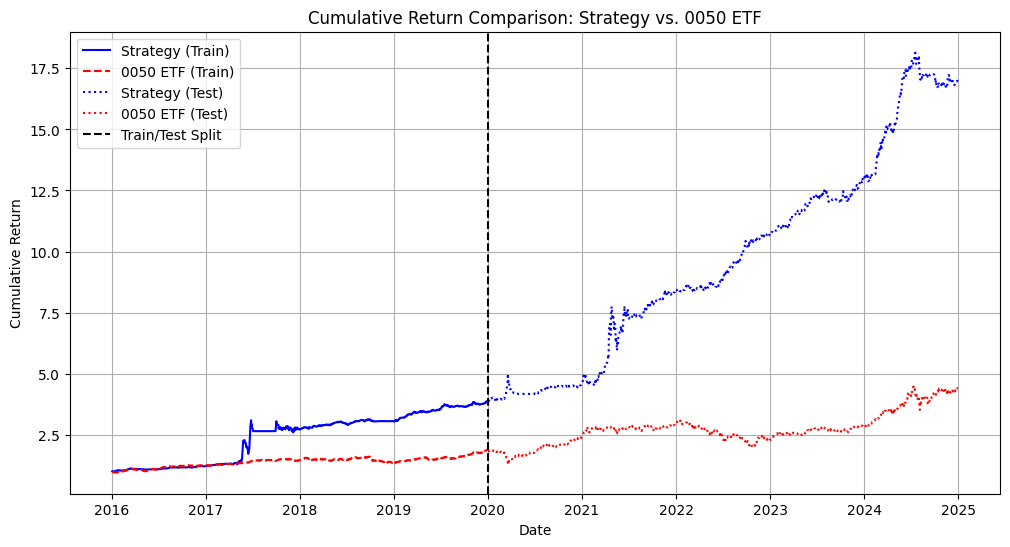

In [116]:
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import pandas as pd

# **下載 0050 (元大台灣50) 的歷史數據**
etf_0050 = yf.download("0050.TW", start="2016-01-01", end="2024-12-31", progress=False)["Adj Close"]

# **計算 0050 的日報酬率**
etf_0050_returns = etf_0050.pct_change().dropna()

# **計算 0050 的累積報酬**
cumulative_etf_0050 = (1 + etf_0050_returns).cumprod()

# **分割策略的累積報酬**
train_strategy = strategy_result["2016-01-01":"2019-12-31"]
test_strategy = strategy_result["2020-01-01":"2024-12-31"]

train_0050 = cumulative_etf_0050["2016-01-01":"2019-12-31"]
test_0050 = cumulative_etf_0050["2020-01-01":"2024-12-31"]

# **繪製累積報酬圖**
plt.figure(figsize=(12, 6))

# 訓練期
plt.plot(train_strategy / train_strategy.iloc[0], label="Strategy (Train)", color="blue")
plt.plot(train_0050 / train_0050.iloc[0], label="0050 ETF (Train)", color="red", linestyle="--")

# 測試期
plt.plot(test_strategy / train_strategy.iloc[0], label="Strategy (Test)", color="blue", linestyle="dotted")
plt.plot(test_0050 / train_0050.iloc[0], label="0050 ETF (Test)", color="red", linestyle="dotted")

# **標示**
plt.axvline(pd.Timestamp("2020-01-01"), color="black", linestyle="--", label="Train/Test Split")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Return Comparison: Strategy vs. 0050 ETF")
plt.legend()
plt.grid(True)

# **顯示圖表**
plt.show()
